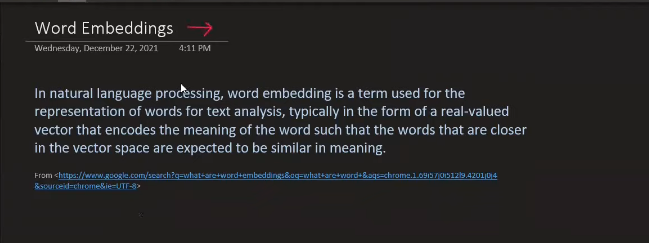

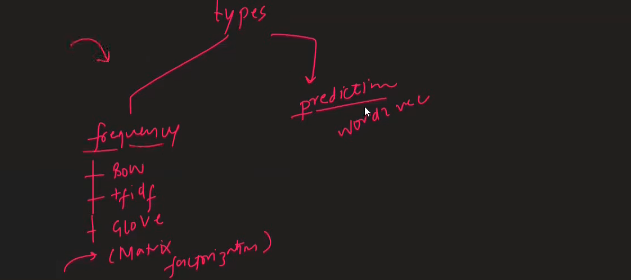

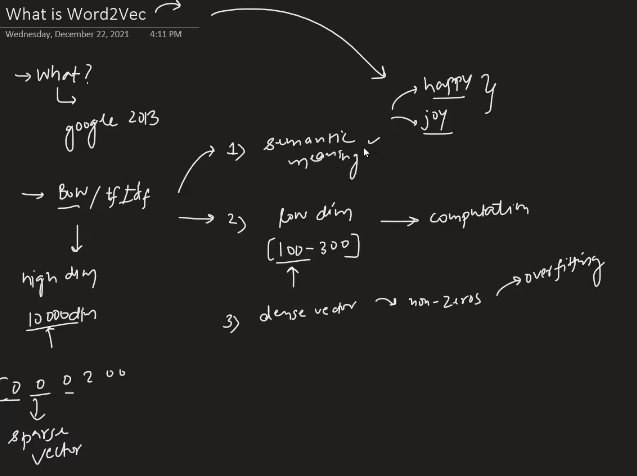

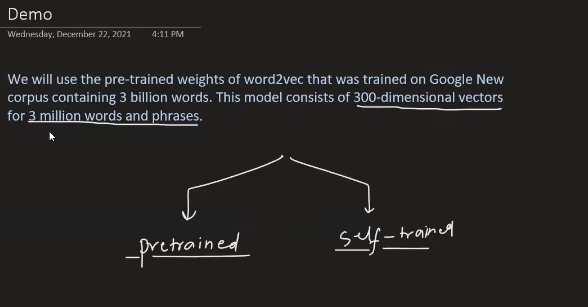

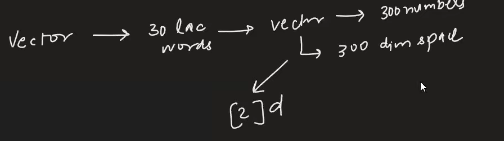

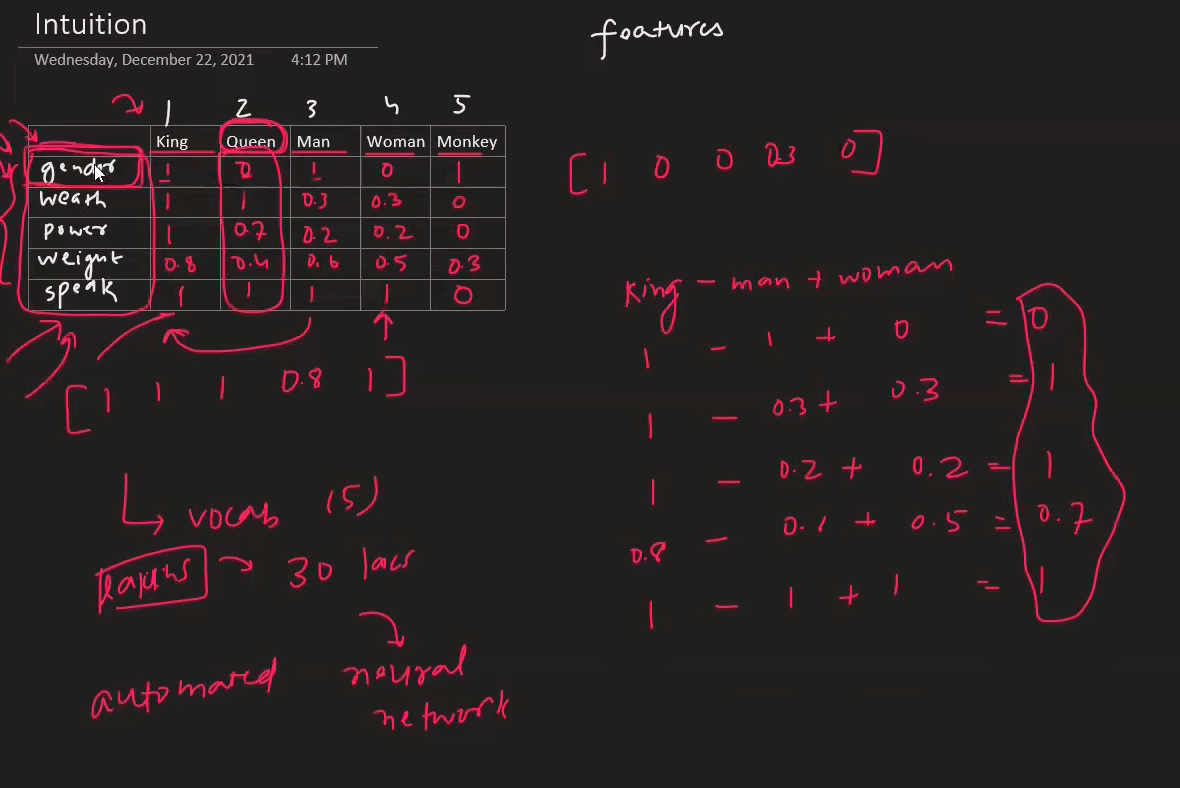

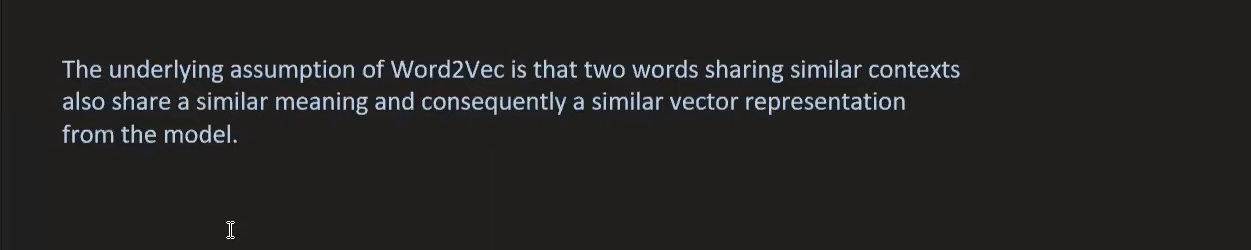

Word2Vec is a sophisticated, **prediction-based word embedding technique** that represents words as real-valued vectors (collections of numbers). It was developed by Google engineers in 2013. Unlike older frequency-based techniques like Bag-of-Words (BoW) or TF-IDF, Word2Vec captures the **semantic meaning** of words, understanding that similar words (like "Happy" and "Joy") should have similar vector representations.

Here is an in-depth summary of Word2Vec's mechanisms, advantages, and a detailed look at its implementation using Python code based on the sources.

---

## 1. Word2Vec Concepts and Internal Working

### Key Advantages over Traditional Embeddings
Word2Vec offers significant improvements compared to frequency-based techniques like BoW and TF-IDF:

1.  **Semantic Meaning Capture:** It captures the semantic relationship between words, ensuring that words used in similar contexts have similar vector representations.
2.  **Low Dimensionality:** The resulting word vectors are low-dimensional (e.g., typically 100 to 300 numbers), making computation faster. This is in contrast to older techniques that could result in high-dimensional vectors, potentially 10,000 dimensions or more.
3.  **Dense Vectors:** Word2Vec produces **dense vectors**, meaning most of the values within the vector are non-zero. This avoids issues like overfitting that are associated with the sparse vectors created by BoW and TF-IDF.

### The Core Logic (Context is King)
The fundamental observation underlying Word2Vec is that **two words sharing similar contexts also share similar meaning and, consequently, similar vector representations**.

To generate these vectors, Word2Vec employs a deep learning model (a shallow neural network) to solve a *dummy prediction problem*. The resulting vector representation is merely a **byproduct** of training this model.

### Word2Vec Architectures
There are two main architectures for Word2Vec, both based on neural networks:

1.  **Continuous Bag-of-Words (CBOW):**
    *   **Dummy Problem:** Given a set of surrounding **context words**, CBOW predicts the **target word** (the center word).
    *   **Application:** Generally faster and tends to yield better results when working with **smaller datasets**.

2.  **Skip-gram:**
    *   **Dummy Problem:** This is the reverse of CBOW. Given a single **target word**, Skip-gram predicts the surrounding **context words**.
    *   **Application:** Generally produces better results when working with **large datasets**.

### Vector Extraction Process (Neural Network Weights)
The vector representation itself is derived from the weights of the hidden layer in the neural network.

*   If a model is configured to produce vectors with $N$ dimensions, the hidden layer will contain $N$ nodes (e.g., 3 nodes if the desired vector size is 3).
*   When the neural network is trained (through multiple epochs) to minimize the prediction loss (using backpropagation), the weights connecting the input layer to the hidden layer are adjusted.
*   Once training is complete, the vector representation for any given word is simply the **values of the weights** associated with that word leading into the hidden layer.

### Factors Affecting Quality
The quality of Word2Vec embeddings can be improved by:
*   Increasing the **training data** (more data is better).
*   Increasing the **dimension of the vectors** (more notes in the hidden layer).
*   Increasing the **window size** (the number of context words examined on either side of the target word).

## 2. In-Depth Implementation using Gensim (Game of Thrones Data)

The source demonstrates training a custom Word2Vec model on the text content of five *Game of Thrones* books using the `Gensim` library.

### A. Setup and Data Preparation

The first step is importing necessary libraries and processing the raw text corpus (all five GoT books) into a format suitable for the Word2Vec model: a list of tokenized sentences.

```python
# 1. Import necessary modules
import gensim
from gensim.models.word2vec import Word2Vec
from nltk.tokenize import sent_tokenize
import os

# Assume 'data' folder contains text files for the GoT books
story = []
data_folder = 'data'

# 2. Iterate through files and process content
for filename in os.listdir(data_folder):
    filepath = os.path.join(data_folder, filename)
    
    # Read content from the text file
    with open(filepath, 'r') as f:
        corpus_content = f.read()

    # Convert the string content into separate sentences using NLTK
    sentences = sent_tokenize(corpus_content)
    
    # Preprocess each sentence and store it in the 'story' list
    # The 'simple_process' function (from Gensim) performs basic level preprocessing
    for sentence in sentences:
        processed_sentence = gensim.utils.simple_preprocess(sentence)
        story.append(processed_sentence)

# The 'story' list now holds all sentences, tokenized into words
# (e.g., [[the, wildling, roared], [this, is, a, longer, sentence], ...])
# The total number of sentences in this corpus was 55,488.
```

### B. Model Building and Training

Next, the `Word2Vec` object is configured and trained using the prepared `story` corpus.

```python
# 1. Configure the Word2Vec model parameters
model = Word2Vec(
    # The minimum count ensures that words appearing fewer than 2 times are ignored.
    min_count = 2,
    
    # Vector size determines the dimension of the resulting word vectors.
    # Here, 100 numbers (dimensions) will represent each word.
    vector_size = 100,
    
    # The window size (10) means the model looks at 10 words on either side of the target word
    # when determining context for training.
    window = 10
)

# 2. Build the vocabulary
# Extracts all unique words from the corpus.
model.build_vocab(story)

# 3. Train the model
model.train(
    # Pass the tokenized corpus
    corpus_iterable = story,
    
    # total_examples is the total number of sentences in the corpus.
    total_examples = model.corpus_count,
    
    # epochs defines how many times the model iterates over the entire dataset.
    epochs = 5
)
```

### C. Using the Trained Model

Once trained, the resulting word vectors are stored internally within the model object, accessible via `model.wv` (Word Vectors).

#### 1. Finding Semantically Similar Words
This function uses cosine similarity to find words whose vectors are closest to the vector of the input word.

```python
# Find words similar to "daenerys"
model.wv.most_similar('daenerys')

# Example Output (as seen in source, reflecting logical connections):
# [(probation, 0.90), (monarch, 0.88), (gregorian, 0.85), (prince, 0.82), ...]
```

#### 2. Vector Arithmetic (Odd One Out)
The `doesnt_match` function performs vector arithmetic to find the word that is least similar to the others.

```python
# Find the odd-one-out among the Stark siblings
# (Jon is flagged as odd because he is not biologically a Stark child).
model.wv.doesnt_match(['jon', 'robb', 'arya', 'sansa', 'bran'])

# Output: 'jon'
```

#### 3. Calculating Similarity Between Words
The `similarity` function calculates the cosine similarity between two word vectors (scores are close to 1 for high similarity and 0 for no similarity).

```python
# Calculate similarity between two sisters (Arya and Sansa)
model.wv.similarity('arya', 'sansa')

# Output: 0.85 (High similarity, which is logical)

# Calculate similarity between two unrelated characters (Daenerys and Sansa)
model.wv.similarity('daenerys', 'sansa')

# Output: Low score (e.g., 0.3)
```

#### 4. Accessing Raw Vector Representation
You can directly retrieve the 100-dimensional vector for any word.

```python
# Get the vector for 'king'
vector = model.wv['king']

# Output: A 1D array of 100 float numbers
```

### D. Visualizing Embeddings (Dimensionality Reduction)

To visualize the high-dimensional vectors (e.g., 100 dimensions) in a 2D or 3D plot, **dimensionality reduction techniques** like Principal Component Analysis (PCA) or t-distributed Stochastic Neighbor Embedding (t-SNE) must be applied.

The source uses PCA to reduce the vector space from 100 dimensions down to 3 dimensions (`n_components=3`).

```python
from sklearn.decomposition import PCA

# 1. Get all trained vectors
all_vectors = model.wv.get_normed_vectors()
# Shape of all_vectors: (1743, 100) -> 17,430 unique words, 100 dimensions each.

# 2. Initialize PCA and reduce dimensions to 3
pca = PCA(n_components=3)

# Fit and transform the vectors
reduced_vectors = pca.fit_transform(all_vectors)
# Shape of reduced_vectors: (1743, 3).

# 3. Plotting the results (only the first 100 most frequent words were plotted
# due to computational constraints).
# In the 3D plot, words used in similar contexts (e.g., 'sir' and 'lady', 'down' and 'up')
# appeared close together.
```

The Word2Vec model uses two primary architectures, **Continuous Bag-of-Words (CBOW)** and **Skip-gram**, both of which rely on training a shallow neural network to solve a **dummy prediction problem**. The resulting word vector (or embedding) is not the goal itself, but rather a **byproduct** of training this predictive model.

The core logic guiding both architectures is the **underlying observation that two words sharing similar contexts also share similar meaning and, consequently, similar vector representations**.

Here is an in-depth breakdown of how CBOW and Skip-gram work:

---

## 1. Continuous Bag-of-Words (CBOW)

### The Dummy Problem
In the CBOW architecture, the dummy prediction problem is defined as: **Given the surrounding context words, predict the target word (the word in the center)**.

### Training Data Creation
Training data is created by using a sliding "window" over the text corpus. If the window size is defined as three words, the center word is the target, and one word on either side acts as context.

| Example Corpus: "Watch Camps For Data Science" |
| :--- |
| **Input (Context):** ["Watch", "For"] | **Output (Target):** "Camps" |
| **Input (Context):** ["Camps", "Data"] | **Output (Target):** "For" |

### Neural Network Architecture
The CBOW model is a neural network designed to map the input context words to the output target word.

1.  **Input Layer:** The words in the corpus are first converted into **One-Hot Encoded (OHE) vectors**. The input layer takes these OHE vectors representing the context words.
2.  **Hidden Layer:** This layer is critical because the **number of nodes in the hidden layer determines the dimension of the final word vector**. If you want a 3-dimensional vector, the hidden layer will have three nodes.
3.  **Output Layer:** This layer uses a **SoftMax layer**. It contains nodes equal to the size of the entire vocabulary, and its job is to assign a probability to every word in the vocabulary, predicting which word is the most likely target word.

### Training and Vector Extraction
1.  **Training:** The network is trained using the training data created above. The input (context OHE vectors) is passed forward, and a prediction is made. This prediction is compared against the actual target word (which is also represented as an OHE vector, e.g., 01000 for "Camps" if "Camps" is the second word in the vocabulary).
2.  **Loss Calculation and Backpropagation:** A loss is calculated based on the difference between the predicted probability distribution and the true target word. This loss is **backpropagated** through the network to adjust the weights between the layers. This process is repeated over multiple epochs until the loss is minimized.
3.  **Vector Extraction:** Once training is complete, the vector representation (the embedding) for a specific word (e.g., "Watch") is simply the **values of the weights** connecting the input layer node corresponding to "Watch" to all the nodes in the hidden layer.

### CBOW Use Case
CBOW tends to be **faster** and generally yields better results when working with **smaller datasets**.

---

## 2. Skip-gram

### The Dummy Problem
The Skip-gram architecture reverses the CBOW problem. The prediction problem is: **Given a single target word (center word), predict the surrounding context words**.

### Training Data Creation
Using the same window size (e.g., 3 words), the target word becomes the input, and the context words become the outputs.

| Example Corpus: "Watch Camps For Data Science" |
| :--- |
| **Input (Target):** "Camps" | **Output (Context):** ["Watch", "For"] |
| **Input (Target):** "For" | **Output (Context):** ["Camps", "Data"] |

### Neural Network Architecture
The overall architecture is inverted relative to CBOW:
1.  **Input Layer:** Takes the OHE vector of the single target word (e.g., OHE for "Camps").
2.  **Hidden Layer:** Functions identically to CBOW, determining the dimension of the output vector (e.g., 3 nodes for a 3-dimensional vector).
3.  **Output Layer:** Must predict multiple context words simultaneously. If the vocabulary size is $V$ and the window size requires predicting $C$ context words, the output structure is designed to handle $C$ predictions over the $V$ vocabulary words.

### Training and Vector Extraction
The training mechanism (loss calculation, backpropagation, and weight adjustment) is essentially the same as CBOW.

*   **Vector Extraction:** After training, the word embeddings are derived from the **weights connecting the input layer node to the hidden layer**.

### Skip-gram Use Case
Skip-gram generally produces **better results** when working with **large datasets**.

---

## Factors Affecting Vector Quality

Regardless of the architecture used, the quality of the Word2Vec embeddings can be improved by:

1.  **Increasing the training data:** More data provides better context.
2.  **Increasing the dimension of the vectors:** Increasing the number of nodes in the hidden layer (e.g., from 100 to 200 or 300).
3.  **Increasing the window size:** Looking at more words on either side of the target word captures broader context.

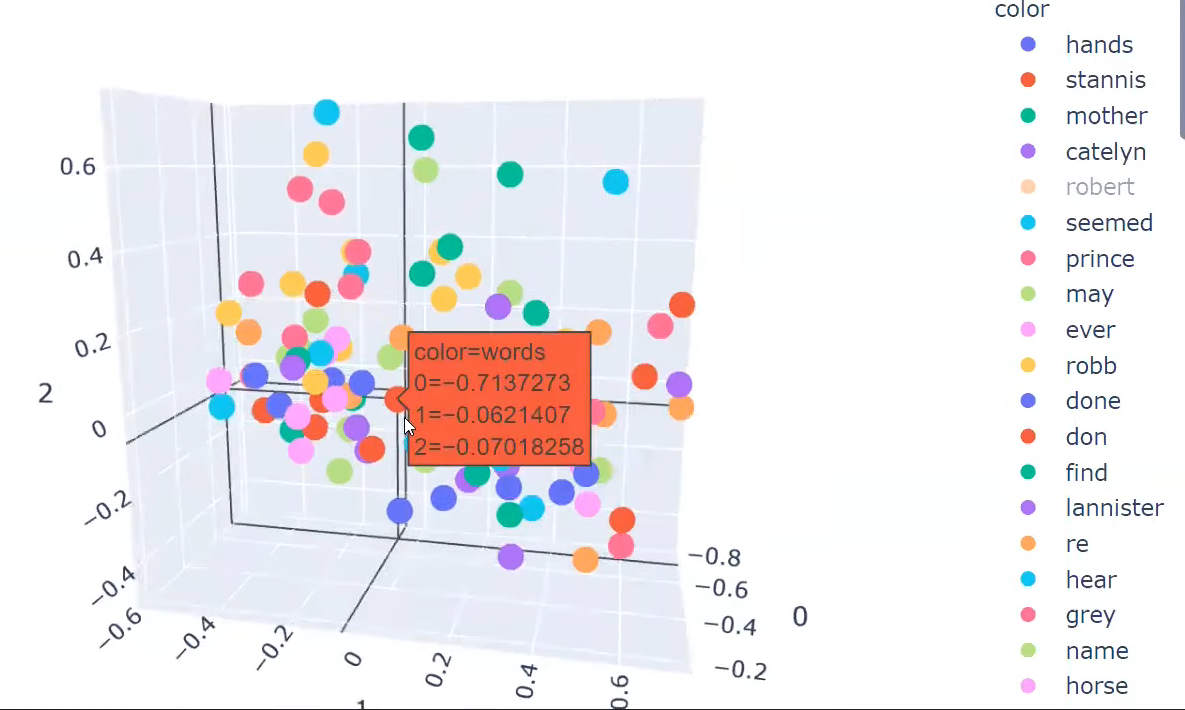